# Preliminaries and Ablations

## Synchronization and request heterogeneity

The data come from `Synchronization and request rates/script.py`, which reads `setup.json` and writes `result.pkl` in the same folder.

In [1]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'Synchronization and request rates' / 'result.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'Synchronization and request rates' / 'result.pkl' for root in search_roots]
data_path = next((path for path in candidates if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError('Run Synchronization and request rates/script.py first.')
with data_path.open('rb') as file:
    data = pickle.load(file)
class_colors = ['#1B67E2', '#704881', '#5F923F', '#541E09']
print(f'Loaded {len(data["scenarios"])} scenarios from {data_path}')

Loaded 2 scenarios from C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Synchronization and request rates\result.pkl


### $\gamma_{\mathrm{heter}} = 0.1$, $\gamma_{\mathrm{sync}} = 1$

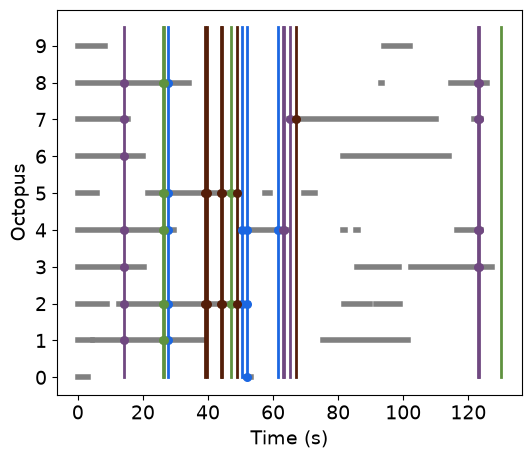

In [2]:
scenario = data['scenarios'][0]
global_iterations_instants = scenario['global_iterations_instants']
activation_periods = scenario['activation_periods']
triggering_events_instants = scenario['triggering_events_instants']

plt.figure(figsize=(6, 5))
max_display_Octopi = 10
for i in range(max_display_Octopi):
    for period in activation_periods[i]:
        plt.plot(period, (i, i), color='grey', linewidth=4)
    for c in range(4):
        for z in triggering_events_instants[i][c]:
            plt.scatter([z], [i], s=30, color=class_colors[c], zorder=3)

for c in range(4):
    for y in global_iterations_instants[c]:
        plt.plot([y] * 2, [0, max_display_Octopi - .5], color=class_colors[c], alpha=1, linewidth=2, zorder=2)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Octopus', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(range(10), fontsize=14)
plt.show()

### $\gamma_{\mathrm{heter}} = 8$, $\gamma_{\mathrm{sync}} = 0.2$

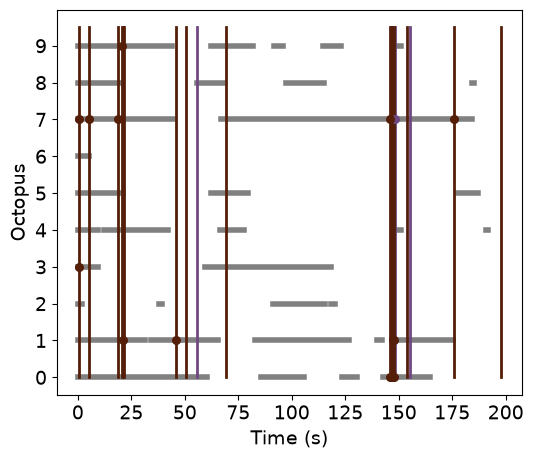

In [3]:
scenario = data['scenarios'][1]
global_iterations_instants = scenario['global_iterations_instants']
activation_periods = scenario['activation_periods']
triggering_events_instants = scenario['triggering_events_instants']

plt.figure(figsize=(6, 5))
max_display_Octopi = 10
for i in range(max_display_Octopi):
    for period in activation_periods[i]:
        plt.plot(period, (i, i), color='grey', linewidth=4)
    for c in range(4):
        for z in triggering_events_instants[i][c]:
            plt.scatter([z], [i], s=30, color=class_colors[c], zorder=3)

for c in range(4):
    for y in global_iterations_instants[c]:
        plt.plot([y] * 2, [0, max_display_Octopi - .5], color=class_colors[c], alpha=1, linewidth=2, zorder=2)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Octopus', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(range(10), fontsize=14)
plt.show()

## Role of the fitness margins

The data come from `Fitness margins/script.py`, which reads `setup.json` and writes `result.pkl`.

In [4]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'Fitness margins' / 'result.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'Fitness margins' / 'result.pkl' for root in search_roots]
fitness_result_path = next((path for path in candidates if path.is_file()), None)
if fitness_result_path is None:
    raise FileNotFoundError('Run Fitness margins/script.py first.')
with fitness_result_path.open('rb') as file:
    fitness_result = pickle.load(file)

def plot_fitness_margin(scenario, disc_size):
    class_index = fitness_result['setup']['plot']['class_index']
    display_horizon = fitness_result['setup']['plot']['display_horizon']
    reference = fitness_result['scenarios'][0]
    reference_fitness = reference['fitness_history'][class_index][:, :display_horizon + 1]
    reference_freshness = reference['freshness_history'][class_index][:, :display_horizon + 1]
    max_fitness, min_fitness = reference_fitness.max(), reference_fitness.min()
    max_freshness, min_freshness = reference_freshness.max(), reference_freshness.min()
    cmap = plt.get_cmap('coolwarm')
    norm = mcolors.Normalize(vmin=min_freshness, vmax=max_freshness)
    fitness_history = scenario['fitness_history'][class_index]
    freshness_history = scenario['freshness_history'][class_index]
    contributing_history = scenario['contributing_octopi_history'][class_index]
    candidate_history = scenario['candidate_octopi_history'][class_index]

    plt.figure(figsize=(6, 5))
    for i in range(min(len(contributing_history), display_horizon + 1)):
        contributing = set(contributing_history[i])
        candidates_not_contributing = set(candidate_history[i]) - contributing
        j = 0
        for agent_id in sorted(contributing):
            fitness_size = disc_size * (fitness_history[agent_id, i] - min_fitness) / (max_fitness - min_fitness - 10) + 5
            color = cmap(norm(freshness_history[agent_id, i]))
            plt.scatter(i, j, s=fitness_size, color=color)
            j += 1
        for agent_id in sorted(candidates_not_contributing):
            fitness_size = disc_size * (fitness_history[agent_id, i] - min_fitness) / (max_fitness - min_fitness) + 5
            freshness_intensity = (freshness_history[agent_id, i] - min_freshness) / (max_freshness - min_freshness)
            freshness_intensity = max(freshness_intensity, .6)
            plt.scatter(i, j, s=fitness_size, alpha=freshness_intensity, color='grey')
            j += 1
    plt.xlabel('Iterations', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks([], fontsize=12)
    plt.ylabel('Local policies', fontsize=14)
    plt.show()

print(f'Loaded {len(fitness_result["scenarios"])} fitness-margin scenarios from {fitness_result_path}')

Loaded 2 fitness-margin scenarios from C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Fitness margins\result.pkl


### Fitness margin = 0

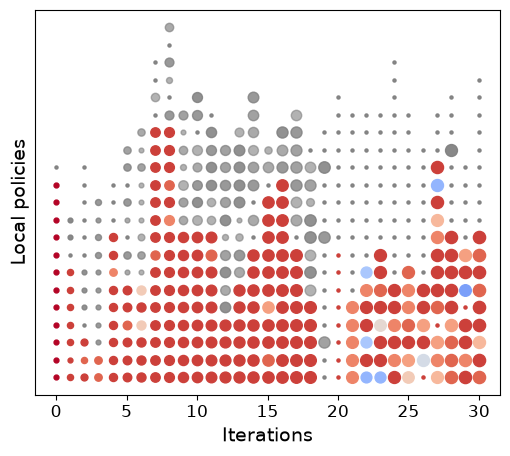

In [5]:
plot_fitness_margin(fitness_result['scenarios'][0], fitness_result['setup']['plot']['disc_sizes'][0])

### Fitness margin = 10

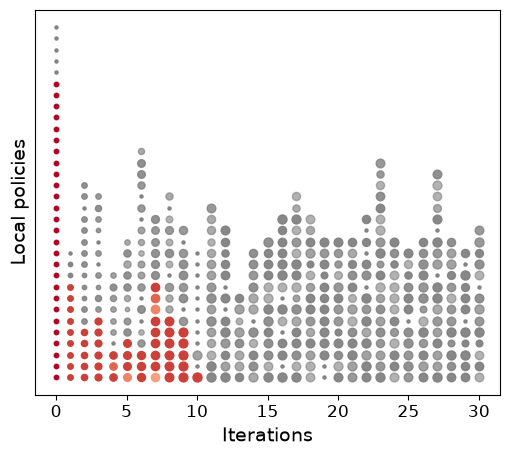

In [6]:
plot_fitness_margin(fitness_result['scenarios'][1], fitness_result['setup']['plot']['disc_sizes'][1])

## Planet gravity

`Planet gravity/script.py` uses the Ant Xi matrix and Gamma-sampled planet gravities. Ten local octopi contribute every five episodes; an additional Ant at Earth gravity is evaluated after each round. Each gravity variance runs for 400 episodes and 10 repetitions.

In [7]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'Planet gravity' / 'result.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'Planet gravity' / 'result.pkl' for root in search_roots]
gravity_result_path = next((path for path in candidates if path.is_file()), None)
if gravity_result_path is None:
    raise FileNotFoundError('Run Planet gravity/script.py first.')
with gravity_result_path.open('rb') as file:
    gravity_result = pickle.load(file)

def plot_gravity_rewards(scenarios, labels):
    plt.figure(figsize=(5, 4.5))
    for scenario, label in zip(scenarios, labels):
        data = scenario['rewards']
        mean = data.mean(axis=0) / 1000
        std = data.std(axis=0) / 1000
        x = np.arange(len(mean))
        plt.plot(x, mean, label=label)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)
    plt.grid(True)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Cumulative reward', fontsize=14)
    plt.legend(loc='lower right', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    ax = plt.gca()
    ax.text(x=-.15, y=0, s=r'$\times 10^{3}$', transform=ax.transAxes, fontsize=12, va='top', ha='left')
    plt.tight_layout()
    plt.show()

print(f'Loaded gravity data from {gravity_result_path}')

Loaded gravity data from C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Planet gravity\result.pkl


### Gravity variance

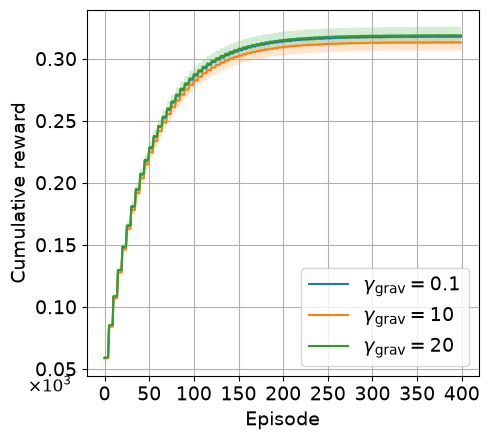

In [8]:
plot_gravity_rewards(
    gravity_result['scenarios'],
    [rf'$\gamma_{{\mathrm{{grav}}}} = {item["gamma_grav"]:g}$' for item in gravity_result['scenarios']],
)

## Octopi count

`Octopi count/script.py` fixes $\gamma_{\mathrm{grav}}=10$ and compares $M=10, 20, 30$ octopi over 400 episodes, with 10 repetitions each. Both experiments aggregate simulated local fitness and evaluate an Earth-gravity Ant. Simulated rewards do not train policy weights, so these are model-based results rather than policy-parameter FedAvg. The current Xi coefficients are test values, not calibrated estimates.

In [9]:
from pathlib import Path
import pickle

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'Octopi count' / 'result.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'Octopi count' / 'result.pkl' for root in search_roots]
octopi_count_result_path = next((path for path in candidates if path.is_file()), None)
if octopi_count_result_path is None:
    raise FileNotFoundError('Run Octopi count/script.py first.')
with octopi_count_result_path.open('rb') as file:
    octopi_count_result = pickle.load(file)
print(f'Loaded octopi-count data from {octopi_count_result_path}')

Loaded octopi-count data from C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Octopi count\result.pkl


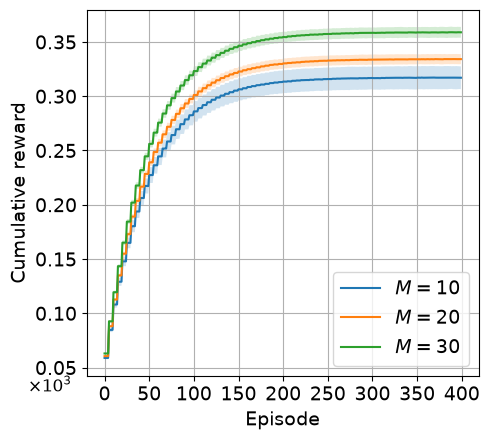

In [10]:
plot_gravity_rewards(
    octopi_count_result['scenarios'],
    [rf'$M = {item["n_octopi"]}$' for item in octopi_count_result['scenarios']],
)

## Fitness margin and temperature

`Temperature/script.py` evaluates Leg/Hopper over 100 class-specific requests at six fitness margins from −5 to 20 and temperatures $\tau=0.01, 1, 3$, matching the paper's class (the source cell in Graphics sets Cheetah). Each point summarizes 10 simulated-reward repetitions; bands show one sample standard deviation. Overhead is plotted in megabytes (MB) of uploaded policy parameters.

In [11]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'Temperature' / 'result.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'Temperature' / 'result.pkl' for root in search_roots]
temperature_result_path = next((path for path in candidates if path.is_file()), None)
if temperature_result_path is None:
    raise FileNotFoundError('Run Temperature/script.py first.')
with temperature_result_path.open('rb') as file:
    temperature_result = pickle.load(file)

def plot_temperature_metric(metric, ylabel, scale=1):
    margins = np.asarray(temperature_result['setup']['fitness_margins'])
    temperatures = temperature_result['setup']['temperatures']
    plt.figure(figsize=(6, 5))
    for index, temperature in enumerate(temperatures):
        mean = temperature_result[f'{metric}_mean'][index] / scale
        std = temperature_result[f'{metric}_std'][index] / scale
        label = rf'$\tau$ = {float(temperature)}'
        plt.plot(margins, mean, label=label)
        plt.fill_between(margins, mean - std, mean + std, alpha=0.2)
    plt.xlabel('Fitness margin', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.show()

print(f'Loaded {temperature_result["setup"]["class_name"]} temperature data from {temperature_result_path}')

Loaded Leg temperature data from C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Temperature\result.pkl


### Overhead

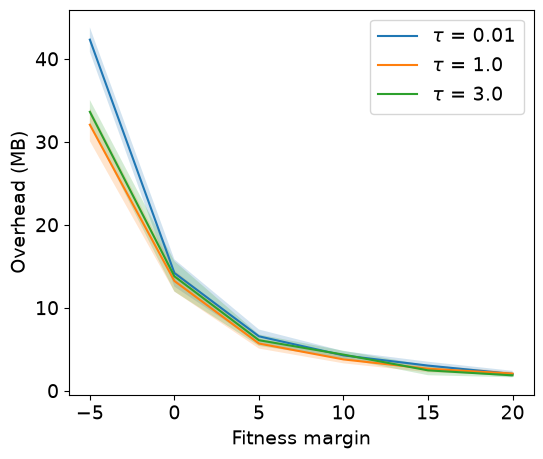

In [12]:
plot_temperature_metric('overhead', 'Overhead (MB)', scale=1_000_000 / 1024)

### Instability

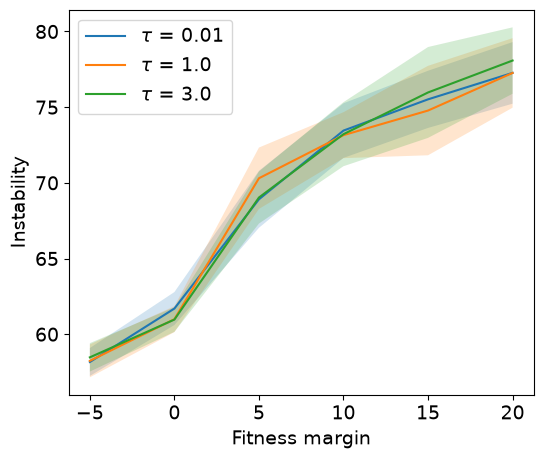

In [13]:
plot_temperature_metric('instability', 'Instability')

## Pareto fronts from Sobol filling

`Pareto fronts/script.py` evaluates 100 scrambled Sobol points for each approach with simulated rewards, using 10 realizations per point. Holistic points set one fitness margin per class over a common horizon of 100 requests; reductionist points set 50 Cheetah margins over 50 class-specific requests. The plots show the first realization at each Sobol point and the expected, RTS, and STR fronts computed from all available realizations.

In [14]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'Pareto fronts' / 'result.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'Pareto fronts' / 'result.pkl' for root in search_roots]
pareto_result_path = next((path for path in candidates if path.is_file()), None)
if pareto_result_path is None:
    raise FileNotFoundError('Run Pareto fronts/script.py first.')
with pareto_result_path.open('rb') as file:
    pareto_result = pickle.load(file)

def plot_pareto_approach(approach):
    mb_per_kb = 1024 / 1_000_000
    points = approach['objectives'][:, 0, :]
    reference = approach['reference_point']
    plt.figure(figsize=(6, 5))
    plt.scatter(points[:, 0] * mb_per_kb, points[:, 1], color='grey', label='Sobol filling')
    plt.scatter(reference[0] * mb_per_kb, reference[1], marker='X', s=80,
                color='black', label='Reference point')
    for key, color, label in (
        ('expected_front', 'green', 'Expected front'),
        ('rts_front', 'red', 'RTS front'),
        ('str_front', 'blue', 'STR front'),
    ):
        front = approach[key]
        plt.plot(front[:, 0] * mb_per_kb, front[:, 1], color=color, linewidth=2, label=label)
    plt.xlabel('Overhead (MB)', fontsize=14)
    plt.ylabel('Instability', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

print(f'Loaded Pareto fronts from {pareto_result_path}')

Loaded Pareto fronts from C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Pareto fronts\result.pkl


### Holistic

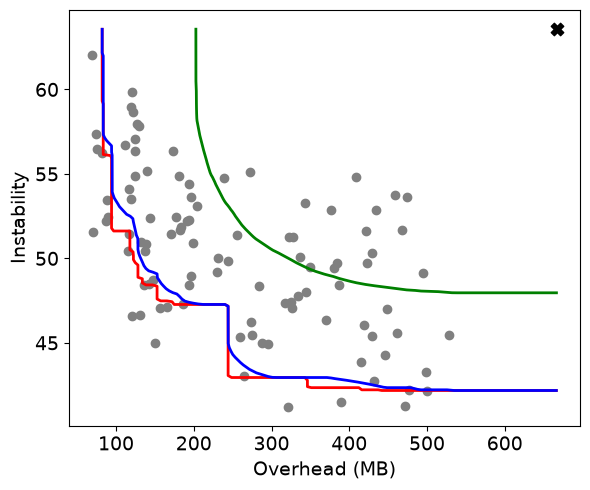

In [15]:
plot_pareto_approach(pareto_result['holistic'])

### Reductionist (Cheetah)

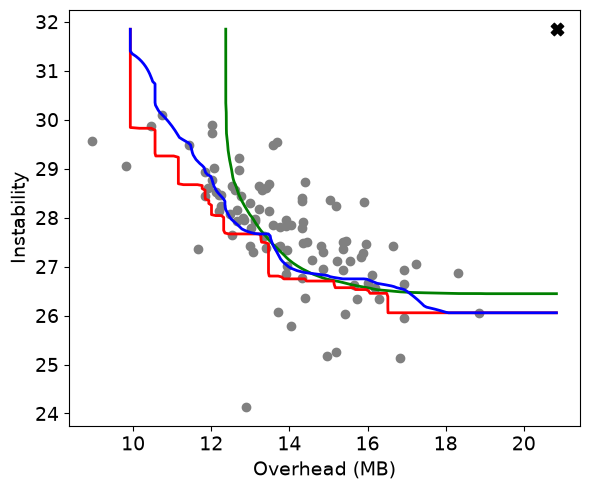

In [16]:
plot_pareto_approach(pareto_result['reductionist'])

## Model calibration: percentage error in overhead and instability

This Figure 13-style Humanoid experiment compares total overhead and instability from the generating Xi matrix with a matrix calibrated from synthetic reward traces. For each of 2, 4, and 6 agents, `Model calibration/script.py` fits the matrix using 2 to 10 synthetic wet experiments in steps of 1, then evaluates both matrices on the same 10 reductionist fitness-margin sequences. Each calibration reward trace has T = 1500 episodes; the separate metric-evaluation horizon remains 50. The plots show root mean square percentage error (RMSPE): 100 times the square root of the mean squared scenario-level error divided by the generating-matrix total. Bands are 90% bootstrap intervals over evaluation sequences. Reward traces come from the generating Xi matrix rather than PPO training, so these curves test the calibration pipeline and its downstream objective predictions, not empirical reward-model accuracy. Ridge regularization uses alpha = max(1000, 2 times the calibration sample count) to stabilize noisy log-OU parameter estimates as the number of agent subsets grows.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'Model calibration' / 'result.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'Model calibration' / 'result.pkl' for root in search_roots]
calibration_result_path = next((path for path in candidates if path.is_file()), None)
if calibration_result_path is None:
    raise FileNotFoundError('Run Model calibration/script.py first.')
with calibration_result_path.open('rb') as file:
    calibration_result = pickle.load(file)

metric_error = calibration_result['metric_error']

def plot_calibration_error(metric_index, ylabel):
    experiments = metric_error['wet_experiment_counts']
    colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
    plt.figure(figsize=(6, 5))
    for agent_index, n_agents in enumerate(metric_error['agent_counts']):
        center = metric_error['root_mean_square_percentage_error'][agent_index, :, metric_index]
        lower = metric_error['rmspe_band_lower'][agent_index, :, metric_index]
        upper = metric_error['rmspe_band_upper'][agent_index, :, metric_index]
        plt.plot(experiments, center, marker='o', markersize=3, color=colors[agent_index],
                 label=f'{n_agents} agents')
        plt.fill_between(experiments, lower, upper, color=colors[agent_index], alpha=0.15)
    plt.xlabel('Number of wet experiments', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(experiments, fontsize=12)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

print(f'Loaded Humanoid calibration data from {calibration_result_path}')

Loaded Humanoid calibration data from C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Model calibration\result.pkl


### Total overhead

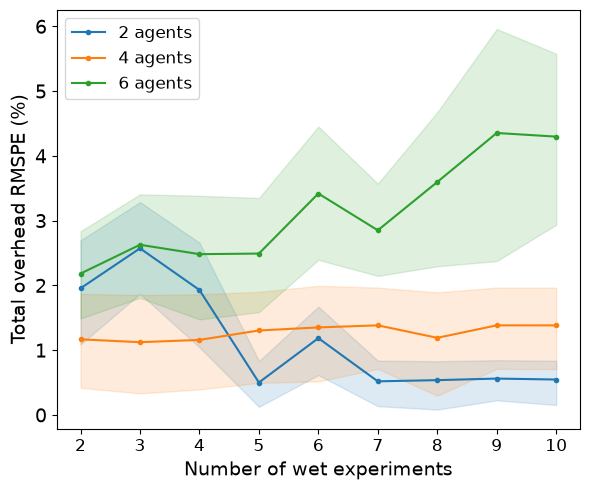

In [2]:
plot_calibration_error(0, 'Total overhead RMSPE (%)')

### Total instability

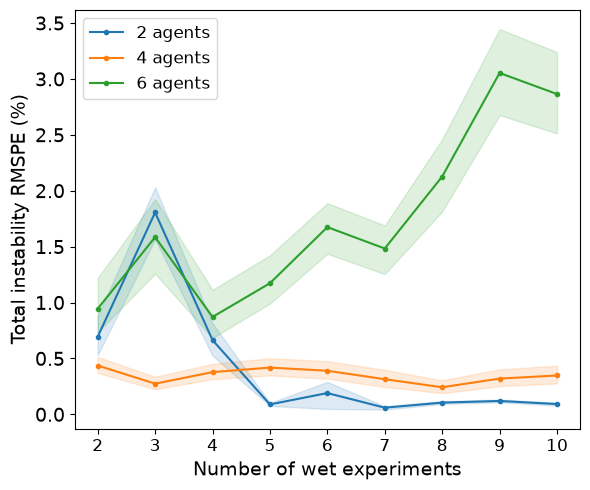

In [3]:
plot_calibration_error(1, 'Total instability RMSPE (%)')